# 03 — Phase 1 Screening Analysis
Analisis hasil 128 eksperimen Phase 1, penetapan Phase 2 groups.

In [12]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import joblib
import warnings
warnings.filterwarnings("ignore")

df_results = pd.read_csv("phase1_screening_results.csv")
df_analysis = pd.read_csv("phase1_screening_analysis.csv")
print("Phase 1 results:", df_results.shape)
print("Screening analysis:", df_analysis.shape)
print("Models:", df_results['Model'].unique().tolist())
print("Windows:", df_results['Window'].unique().tolist())


Phase 1 results: (384, 12)
Screening analysis: (360, 8)
Models: ['RandomForest', 'ExtraTrees', 'XGBoost', 'LightGBM']
Windows: [20, 120]


## 1. Overview: MAPE per Model × Window

In [13]:

# Best result per model × window (covariate = best performer)
mape_col = 'MAPE_mean' if 'MAPE_mean' in df_results.columns else 'MAPE'
pivot = df_results.groupby(['Model', 'Window'])[mape_col].min().unstack()
print("Best MAPE per Model × Window:")
print(pivot.round(4))


Best MAPE per Model × Window:
Window           20      120
Model                       
ExtraTrees    0.6577  0.6586
LightGBM      0.7007  0.6960
RandomForest  0.6588  0.6612
XGBoost       0.6933  0.6957


## 2. Screening Pass/Fail Summary

In [14]:

max_combos = (df_analysis['Model'].nunique()
              * df_analysis['Window'].nunique()
              * df_analysis['Horizon'].nunique())

pass_counts = (
    df_analysis[df_analysis['Passed']]
    .groupby('Covariate').size()
    .rename('pass_count')
    .sort_values(ascending=False)
    .reset_index()
)
pass_counts['max_combos']    = max_combos
pass_counts['pass_rate_pct'] = (pass_counts['pass_count'] / max_combos * 100).round(1)

n_models   = df_analysis['Model'].nunique()
n_windows  = df_analysis['Window'].nunique()
n_horizons = df_analysis['Horizon'].nunique()
print(f"Max combos: {n_models} models × {n_windows} windows × {n_horizons} horizons = {max_combos}")
print(f"Horizons evaluated: {sorted(df_analysis['Horizon'].unique().tolist())}\n")
print(pass_counts.to_string(index=False))


Max combos: 4 models × 2 windows × 3 horizons = 24
Horizons evaluated: [1, 5, 20]

Covariate  pass_count  max_combos  pass_rate_pct
   Silver          14          24           58.3
      STI          11          24           45.8
     Gold          10          24           41.7
   Copper          10          24           41.7
       M2           9          24           37.5
      WTI           9          24           37.5
NPL_Ratio           8          24           33.3
   USDIDR           7          24           29.2
      CPI           6          24           25.0
      GDP           6          24           25.0
  BI_Rate           5          24           20.8
      Tin           3          24           12.5
   Nickel           2          24            8.3
     Coal           1          24            4.2


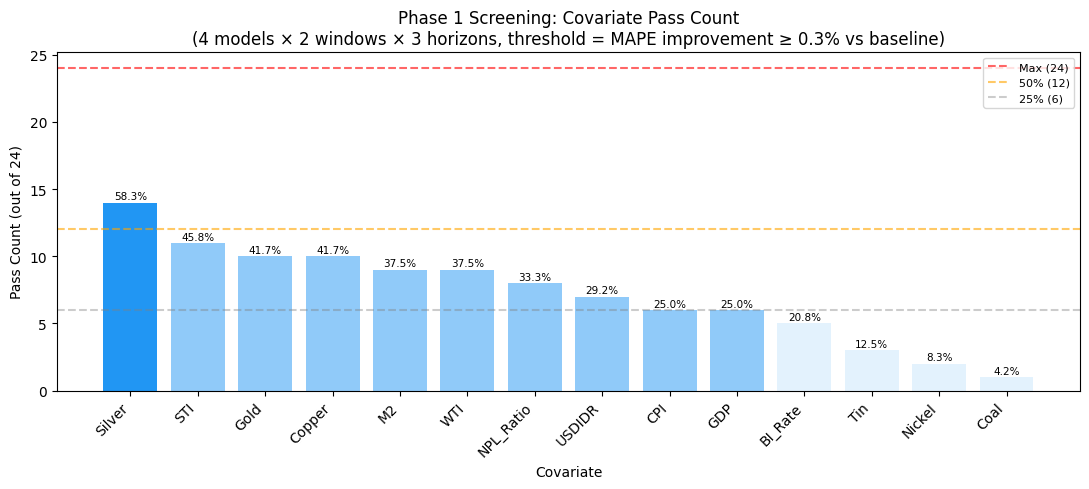

Saved: plot_phase1_screening_summary.png


In [15]:
fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#2196F3' if x >= max_combos * 0.5 else '#90CAF9' if x >= max_combos * 0.25 else '#E3F2FD'
          for x in pass_counts['pass_count']]
ax.bar(pass_counts['Covariate'], pass_counts['pass_count'], color=colors)
ax.axhline(y=max_combos,       color='red',    linestyle='--', alpha=0.6, label=f'Max ({max_combos})')
ax.axhline(y=max_combos * 0.5, color='orange', linestyle='--', alpha=0.6, label=f'50% ({int(max_combos*0.5)})')
ax.axhline(y=max_combos * 0.25,color='gray',   linestyle='--', alpha=0.4, label=f'25% ({int(max_combos*0.25)})')
for bar, row in zip(ax.patches, pass_counts.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            f"{row.pass_rate_pct}%", ha='center', va='bottom', fontsize=7.5)
ax.set_xlabel("Covariate")
ax.set_ylabel(f"Pass Count (out of {max_combos})")
ax.set_title(f"Phase 1 Screening: Covariate Pass Count\n"
             f"({n_models} models × {n_windows} windows × {n_horizons} horizons, "
             f"threshold = MAPE improvement ≥ 0.3% vs baseline)")
ax.legend(fontsize=8)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("plot_phase1_screening_summary.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plot_phase1_screening_summary.png")


## 3. Heatmap: MAPE Improvement per Covariate × Model

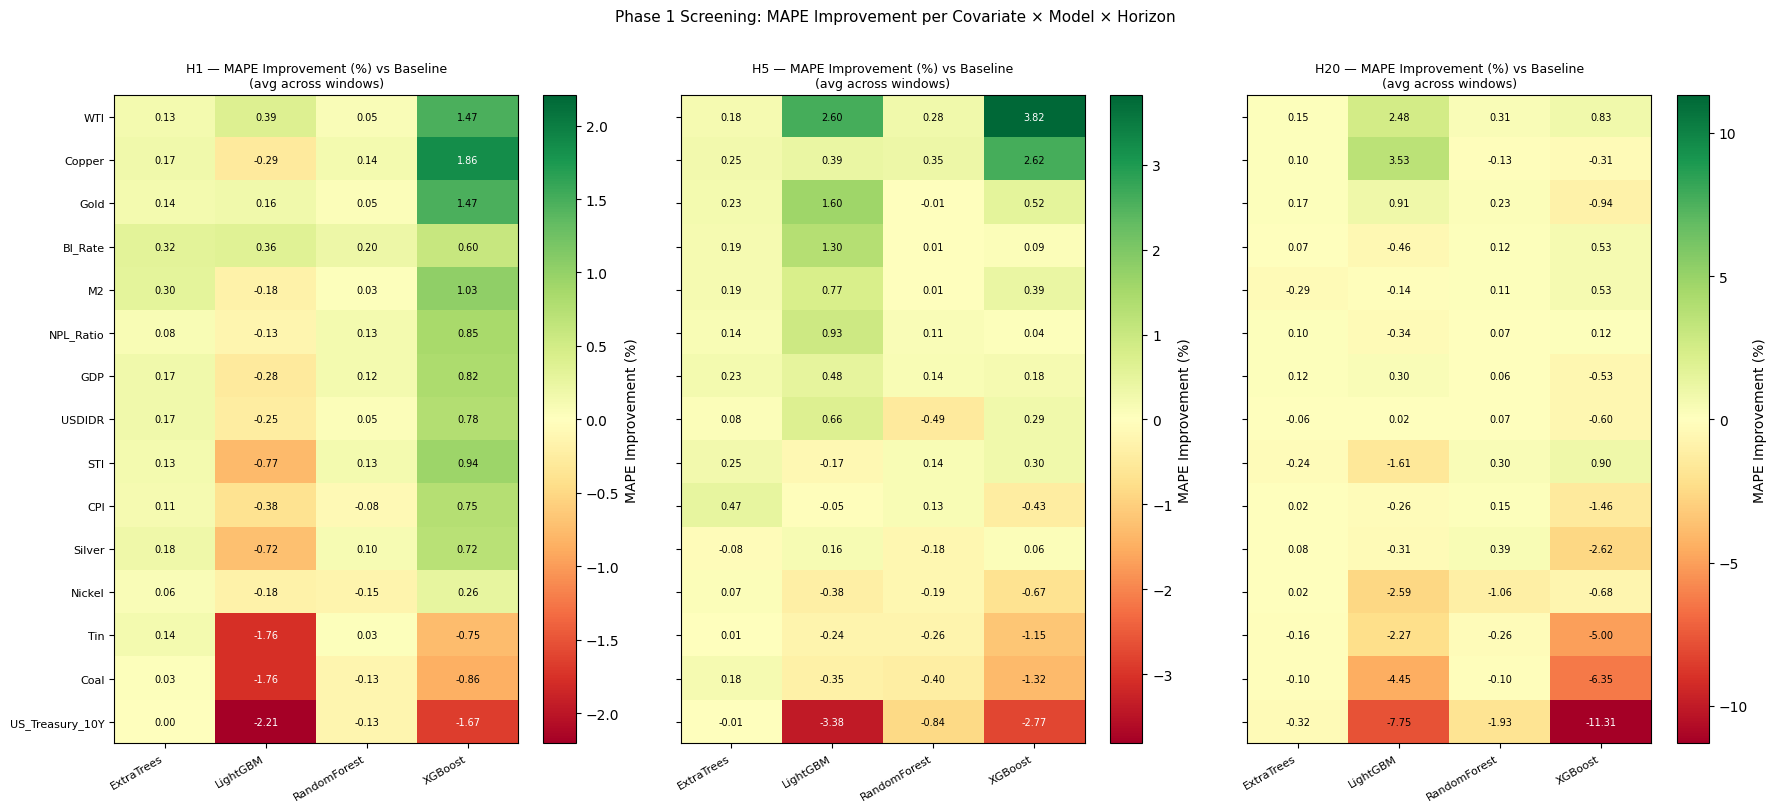

Saved: plot_phase1_heatmap.png


In [9]:

horizons = sorted(df_analysis['Horizon'].unique())
fig, axes = plt.subplots(1, len(horizons), figsize=(6 * len(horizons), 8), sharey=True)
if len(horizons) == 1:
    axes = [axes]

for ax, h in zip(axes, horizons):
    sub = df_analysis[df_analysis['Horizon'] == h]
    heatmap_data = sub.pivot_table(
        values='Improvement_pct', index='Covariate', columns='Model', aggfunc='mean'
    ).fillna(0)

    # Sort baris by rata-rata improvement
    heatmap_data = heatmap_data.loc[heatmap_data.mean(axis=1).sort_values(ascending=False).index]

    vmax = max(abs(heatmap_data.values).max(), 1.0)
    im = ax.imshow(heatmap_data.values, cmap='RdYlGn', aspect='auto', vmin=-vmax, vmax=vmax)
    plt.colorbar(im, ax=ax, label='MAPE Improvement (%)')
    ax.set_xticks(range(len(heatmap_data.columns)))
    ax.set_xticklabels(heatmap_data.columns, rotation=30, ha='right', fontsize=8)
    ax.set_yticks(range(len(heatmap_data.index)))
    ax.set_yticklabels(heatmap_data.index, fontsize=8)
    for i in range(len(heatmap_data.index)):
        for j in range(len(heatmap_data.columns)):
            val = heatmap_data.values[i, j]
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7,
                    color='black' if abs(val) < vmax * 0.7 else 'white')
    ax.set_title(f"H{h} — MAPE Improvement (%) vs Baseline\n(avg across windows)", fontsize=9)

fig.suptitle("Phase 1 Screening: MAPE Improvement per Covariate × Model × Horizon",
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig("plot_phase1_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plot_phase1_heatmap.png")


## 4. Define Phase 2 Groups

In [10]:

MACRO_VARS     = ['BI_Rate', 'CPI', 'M2', 'NPL_Ratio', 'USDIDR', 'GDP', 'US_Treasury_10Y']
COMMODITY_VARS = ['Coal', 'Copper', 'Nickel', 'Silver', 'Tin', 'Gold', 'WTI']
REGIONAL_VARS  = ['STI']

# Threshold: lolos di >= 25% dari total combos (model × window × horizon)
THRESHOLD_PASS = max(2, int(max_combos * 0.25))
passed_covariates = pass_counts[pass_counts['pass_count'] >= THRESHOLD_PASS]['Covariate'].tolist()
print(f"Max combos  : {max_combos}")
print(f"Threshold   : >= {THRESHOLD_PASS} combos ({THRESHOLD_PASS/max_combos*100:.0f}% dari {max_combos})")
print(f"Covariates passing: {passed_covariates}\n")

sig_macro     = [v for v in MACRO_VARS     if v in passed_covariates]
sig_commodity = [v for v in COMMODITY_VARS if v in passed_covariates]
sig_regional  = [v for v in REGIONAL_VARS  if v in passed_covariates]
sig_all       = sig_macro + sig_commodity + sig_regional

GROUP_COVARIATES = {}
if sig_macro:
    GROUP_COVARIATES['Sig_Macro']     = sig_macro
if sig_commodity:
    GROUP_COVARIATES['Sig_Commodity'] = sig_commodity
if sig_regional:
    GROUP_COVARIATES['Sig_Regional']  = sig_regional
if len(sig_all) > 1:
    GROUP_COVARIATES['Sig_All']       = sig_all

print("Phase 2 Groups:")
for k, v in GROUP_COVARIATES.items():
    print(f"  {k} ({len(v)} vars): {v}")


Max combos  : 24
Threshold   : >= 6 combos (25% dari 24)
Covariates passing: ['Silver', 'STI', 'Gold', 'Copper', 'M2', 'WTI', 'NPL_Ratio', 'USDIDR', 'CPI', 'GDP']

Phase 2 Groups:
  Sig_Macro (5 vars): ['CPI', 'M2', 'NPL_Ratio', 'USDIDR', 'GDP']
  Sig_Commodity (4 vars): ['Copper', 'Silver', 'Gold', 'WTI']
  Sig_Regional (1 vars): ['STI']
  Sig_All (10 vars): ['CPI', 'M2', 'NPL_Ratio', 'USDIDR', 'GDP', 'Copper', 'Silver', 'Gold', 'WTI', 'STI']


In [11]:

import os
os.makedirs("saved_models", exist_ok=True)
joblib.dump(GROUP_COVARIATES, "saved_models/phase2_groups.joblib")
print("Saved: saved_models/phase2_groups.joblib")
print(f"Total Phase 2 experiments: {len(GROUP_COVARIATES)} groups × 4 models × 2 windows = {len(GROUP_COVARIATES)*4*2}")


Saved: saved_models/phase2_groups.joblib
Total Phase 2 experiments: 4 groups × 4 models × 2 windows = 32
